In [1]:
import sqlite3
import pandas as pd
import os

In [3]:
# import sqlite3

# 1. Connect with timeout and check_same_thread=False
conn = sqlite3.connect('sales_data.db')

# 2. Create table if it doesn't exist
conn.execute("""CREATE TABLE IF NOT EXISTS sales_data (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            customer_name TEXT NOT NULL,
            
            product_price REAL NOT NULL,
            quantity INTEGER NOT NULL,
            product_name TEXT NOT NULL,
            sale_total REAL GENERATED ALWAYS AS (product_price * quantity) STORED
             
)""")

conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('John Doe', 24.99, 2, 'Washing Powder'))

conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('Samantha', 48, 2,'Fish'))


conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('Jackson', 16.99, 4,'Toilet Paper'))



conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('Michelle', 50, 1,'Cuttlery'))



conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('Ramesh', 20, 3,'Chicken'))



conn.execute("""INSERT INTO sales_data 
                 (customer_name, product_price, quantity, product_name) 
                 VALUES (?, ?, ?, ?)""", 
                 ('Nico', 10, 10,'Eggs'))
conn.commit()

In [4]:
df = pd.read_sql("SELECT * FROM sales_data", conn)

In [5]:
df

,id,customer_name,product_name,product_price,quantity,sale_total
0,1,John Doe,Washing Powder,24.99,2,49.98
1,2,Samantha,Fish,48.00,2,96.00
2,3,Jackson,Toilet Paper,16.99,4,67.96
3,4,Michelle,Cuttlery,50.00,1,50.00
4,5,Ramesh,Chicken,20.00,3,60.00
5,6,Nico,Eggs,10.00,10,100.00


In [6]:
df = pd.read_sql("SELECT sum(product_price*quantity) as total_revenue FROM sales_data", conn)

In [7]:
df

,total_revenue
0,423.94


In [ ]:
df = pd.read_sql("S")

In [13]:
 query = "SELECT product_name, SUM(quantity) AS total_qty, sale_total FROM sales_data GROUP BY product_name, sale_total"

In [14]:
result_df = pd.read_sql(query, conn) 

In [15]:
result_df

,product_name,total_qty,sale_total
0,Chicken,3,60.00
1,Cuttlery,1,50.00
2,Eggs,10,100.00
3,Fish,2,96.00
4,Toilet Paper,4,67.96
5,Washing Powder,2,49.98


<Axes: xlabel='product_name'>

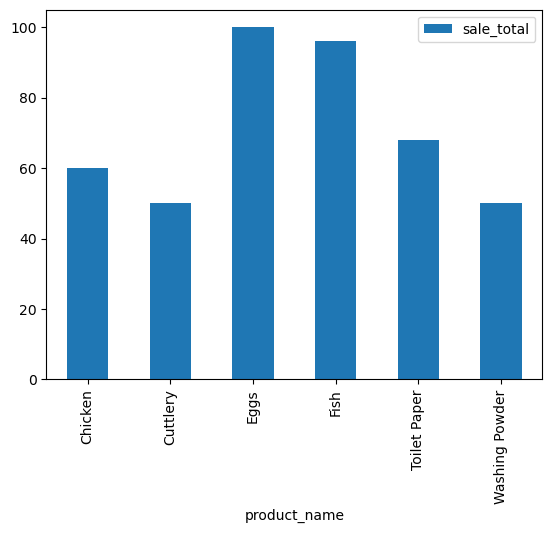

In [16]:
result_df.plot(kind='bar', x='product_name', y='sale_total')